# Box-Cox Transform (Phép biến đổi Box-Cox)



## Box-Cox Transform là gì?


Box-Cox Transform (Phép biến đổi Box-Cox) biến đổi dữ liệu không tuân theo phân phối chuẩn (non-normal) thành dữ liệu giống với phân phối chuẩn (normal distribution).

Tại sao chúng ta cần dữ liệu Time Series (Chuỗi thời gian) tuân theo Normal Distribution (Phân phối chuẩn)? Khi fitting (khớp) một số Model (Mô hình) nhất định như ARIMA, chúng sử dụng Maximum Likelihood Estimation (MLE - Ước lượng hợp lý cực đại) để xác định các Parameter (Tham số). Theo định nghĩa, MLE phải fit với một Distribution (Phân phối) nhất định, thường là Normal Distribution (Phân phối chuẩn) trong hầu hết các thư viện.

Box-Cox Transformation (Phép biến đổi Box-Cox) được tham số hóa bởi λ (lambda, nhận giá trị thực từ -5 đến 5) và biến đổi Time Series (Chuỗi thời gian) y như sau:


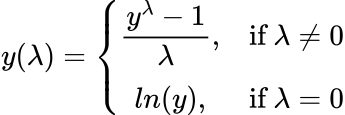

Chúng ta thấy rằng với λ=0 đây là Natural Log Transform (Phép biến đổi logarit tự nhiên), tuy nhiên còn có nhiều phép biến đổi khác tùy thuộc vào giá trị λ.

Ví dụ, nếu λ=0.5 đây là Square Root Transform (Phép biến đổi căn bậc hai), λ=1 không có Transform (Biến đổi) và λ=3 là Cubic Transform (Phép biến đổi lập phương).

Giá trị λ được chọn bằng cách xem giá trị nào xấp xỉ tốt nhất dữ liệu đã Transform (Biến đổi) với Normal Distribution (Phân phối chuẩn). May mắn thay, trong các thư viện tính toán điều này được thực hiện dễ dàng cho chúng ta!


## Trực quan hóa dữ liệu



In [2]:
# Import các thư viện
import plotly.express as px
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import numpy as np
from scipy.stats import boxcox


In [3]:
# Đọc dữ liệu
data = pd.read_csv('AirPassengers.csv')


In [9]:
def plotting(title, data, x, y, x_label, y_label, text=False, lam=None):
    """Hàm chung để vẽ biểu đồ dữ liệu hành khách."""
    # Nếu có giá trị lambda, thêm vào tiêu đề
    if lam is not None:
        title = f"{title}<br>λ = {lam:.3f}"
    
    fig = px.line(data, x=data[x], y=data[y], labels={x: x_label, y: y_label})

    fig.update_layout(template="simple_white", font=dict(size=18),
                      title_text=title, width=650,
                      title_x=0.5, height=400)

    fig.show()


In [10]:
# Vẽ biểu đồ dữ liệu hành khách hàng không
plotting(title='Airline Passengers', data=data, x='Month',
         y='#Passengers', x_label='Date', y_label='Passengers')


Dữ liệu rõ ràng không Stationary (Dừng) vì Mean (Trung bình) và Variance (Phương sai) đều tăng theo thời gian. Để ổn định Variance (Phương sai), chúng ta có thể sử dụng Box-Cox Transform (Phép biến đổi Box-Cox) như đã thảo luận ở trên.


## Áp dụng Box-Cox


In [11]:
# Áp dụng box-cox transform và vẽ biểu đồ
data['Passengers_box_cox'], lam = boxcox(data['#Passengers'])

plotting(title='Airline Passengers', data=data, x='Month', y='Passengers_box_cox',
         x_label='Date', y_label='Passengers<br>Box-Cox Transform', text=True, lam=lam)


Variance (Phương sai) của chúng ta bây giờ đã ổn định và các Fluctuations (Dao động) ở mức nhất quán! Giá trị λ tối ưu là 0.148, gần với Natural Logarithmic Transform (Phép biến đổi logarit tự nhiên) hoàn hảo nhưng chưa hoàn toàn.
